In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [4]:
df = pd.read_csv("Customer_support_data copy.csv")
df.head()


,Unique id,channel_name,category,Sub-category,Customer Remarks,Order_id,order_date_time,Issue_reported at,issue_responded,Survey_response_Date,Customer_City,Product_category,Item_price,connected_handling_time,Agent_name,Supervisor,Manager,Tenure Bucket,Agent Shift,CSAT Score
0,7e9ae164-6a8b-4521-a2d4-58f7c9fff13f,Outcall,Product Queries,Life Insurance,NaN,c27c9bb4-fa36-4140-9f1f-21009254ffdb,NaN,01/08/2023 11:13,01/08/2023 11:47,01-Aug-23,NaN,NaN,NaN,NaN,Richard Buchanan,Mason Gupta,Jennifer Nguyen,On Job Training,Morning,5
1,b07ec1b0-f376-43b6-86df-ec03da3b2e16,Outcall,Product Queries,Product Specific Information,NaN,d406b0c7-ce17-4654-b9de-f08d421254bd,NaN,01/08/2023 12:52,01/08/2023 12:54,01-Aug-23,NaN,NaN,NaN,NaN,Vicki Collins,Dylan Kim,Michael Lee,>90,Morning,5
2,200814dd-27c7-4149-ba2b-bd3af3092880,Inbound,Order Related,Installation/demo,NaN,c273368d-b961-44cb-beaf-62d6fd6c00d5,NaN,01/08/2023 20:16,01/08/2023 20:38,01-Aug-23,NaN,NaN,NaN,NaN,Duane Norman,Jackson Park,William Kim,On Job Training,Evening,5
3,eb0d3e53-c1ca-42d3-8486-e42c8d622135,Inbound,Returns,Reverse Pickup Enquiry,NaN,5aed0059-55a4-4ec6-bb54-97942092020a,NaN,01/08/2023 20:56,01/08/2023 21:16,01-Aug-23,NaN,NaN,NaN,NaN,Patrick Flores,Olivia Wang,John Smith,>90,Evening,5
4,ba903143-1e54-406c-b969-46c52f92e5df,Inbound,Cancellation,Not Needed,NaN,e8bed5a9-6933-4aff-9dc6-ccefd7dcde59,NaN,01/08/2023 10:30,01/08/2023 10:32,01-Aug-23,NaN,NaN,NaN,NaN,Christopher Sanchez,Austin Johnson,Michael Lee,0-30,Morning,5


In [5]:
df.shape

(85907, 20)

In [6]:
df.columns

Index(['Unique id', 'channel_name', 'category', 'Sub-category',
       'Customer Remarks', 'Order_id', 'order_date_time', 'Issue_reported at',
       'issue_responded', 'Survey_response_Date', 'Customer_City',
       'Product_category', 'Item_price', 'connected_handling_time',
       'Agent_name', 'Supervisor', 'Manager', 'Tenure Bucket', 'Agent Shift',
       'CSAT Score'],
      dtype='object')

In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 85907 entries, 0 to 85906
Data columns (total 20 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   Unique id                85907 non-null  object 
 1   channel_name             85907 non-null  object 
 2   category                 85907 non-null  object 
 3   Sub-category             85907 non-null  object 
 4   Customer Remarks         28742 non-null  object 
 5   Order_id                 67675 non-null  object 
 6   order_date_time          17214 non-null  object 
 7   Issue_reported at        85907 non-null  object 
 8   issue_responded          85907 non-null  object 
 9   Survey_response_Date     85907 non-null  object 
 10  Customer_City            17079 non-null  object 
 11  Product_category         17196 non-null  object 
 12  Item_price               17206 non-null  float64
 13  connected_handling_time  242 non-null    float64
 14  Agent_name            

In [8]:
df.isnull().sum()

Unique id                      0
channel_name                   0
category                       0
Sub-category                   0
Customer Remarks           57165
Order_id                   18232
order_date_time            68693
Issue_reported at              0
issue_responded                0
Survey_response_Date           0
Customer_City              68828
Product_category           68711
Item_price                 68701
connected_handling_time    85665
Agent_name                     0
Supervisor                     0
Manager                        0
Tenure Bucket                  0
Agent Shift                    0
CSAT Score                     0
dtype: int64

In [9]:
df.fillna(method='ffill', inplace=True)


C:\Users\nadav\AppData\Local\Temp\ipykernel_15128\4002983762.py:1: FutureWarning: DataFrame.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  df.fillna(method='ffill', inplace=True)


In [10]:
df.duplicated().sum()


np.int64(0)

In [11]:
df.drop_duplicates(inplace=True)


In [14]:
df['CSAT Score'].value_counts()


CSAT Score
5    59617
1    11230
4    11219
3     2558
2     1283
Name: count, dtype: int64

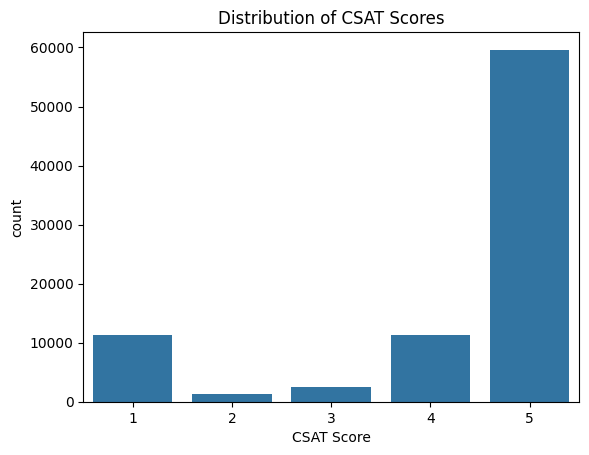

In [15]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.countplot(x='CSAT Score', data=df)
plt.title("Distribution of CSAT Scores")
plt.show()


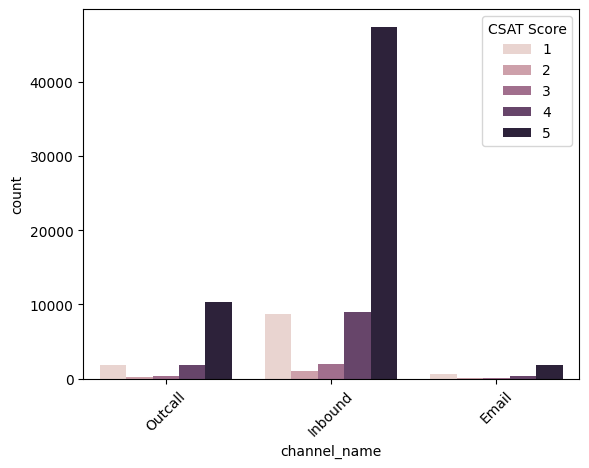

In [16]:
sns.countplot(x='channel_name', hue='CSAT Score', data=df)
plt.xticks(rotation=45)
plt.show()


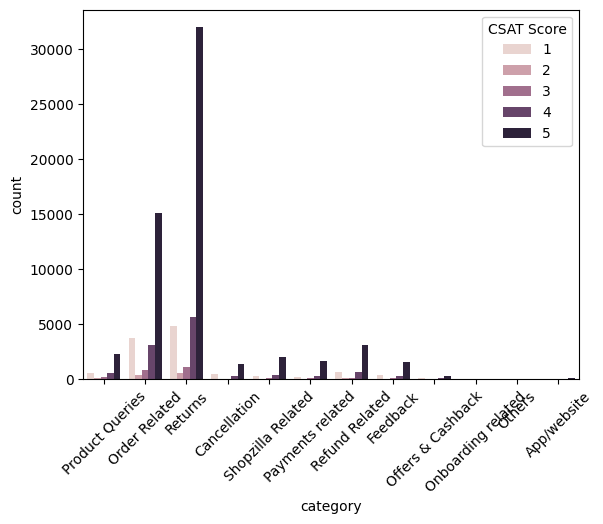

In [17]:
sns.countplot(x='category', hue='CSAT Score', data=df)
plt.xticks(rotation=45)
plt.show()

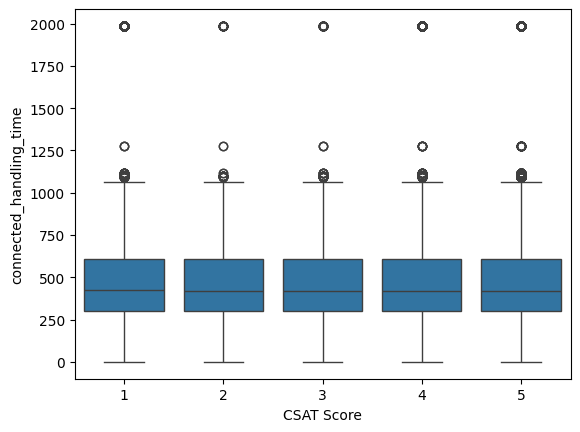

In [18]:
sns.boxplot(x='CSAT Score', y='connected_handling_time', data=df)
plt.show()


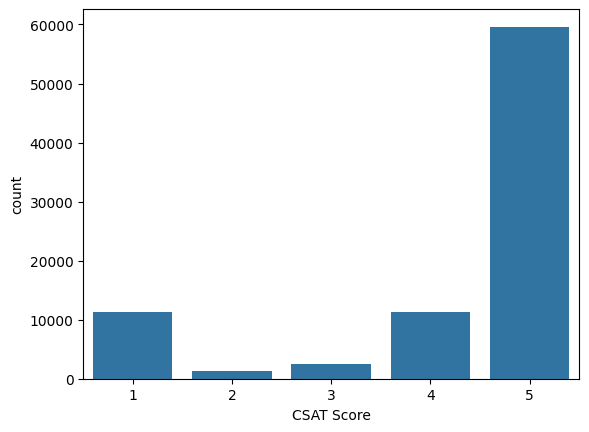

In [19]:
sns.countplot(x='CSAT Score', data=df)
plt.show()


In [20]:
features = [
    'channel_name',
    'category',
    'Sub-category',
    'Agent Shift',
    'Tenure Bucket'
]


In [21]:
target = 'CSAT Score'


In [22]:
X = df[features]
Y = df[target]

In [24]:
from sklearn.preprocessing import LabelEncoder
le =LabelEncoder()
for col in features:
    X[col] = le.fit_transform(X[col])


C:\Users\nadav\AppData\Local\Temp\ipykernel_15128\1242837897.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  X[col] = le.fit_transform(X[col])
C:\Users\nadav\AppData\Local\Temp\ipykernel_15128\1242837897.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  X[col] = le.fit_transform(X[col])
C:\Users\nadav\AppData\Local\Temp\ipykernel_15128\1242837897.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

Se

In [25]:
X.head()


,channel_name,category,Sub-category,Agent Shift,Tenure Bucket
0,2,8,19,2,4
1,2,8,34,2,3
2,1,5,15,1,4
3,1,10,40,1,3
4,1,1,22,2,0


In [27]:
features = [
    'channel_name',
    'category',
    'Sub-category',
    'Agent Shift',
    'Tenure Bucket'
]

X = df[features]
y = df['CSAT Score']


In [28]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()

for col in X.columns:
    X[col] = le.fit_transform(X[col])


C:\Users\nadav\AppData\Local\Temp\ipykernel_15128\3069533735.py:6: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  X[col] = le.fit_transform(X[col])
C:\Users\nadav\AppData\Local\Temp\ipykernel_15128\3069533735.py:6: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  X[col] = le.fit_transform(X[col])
C:\Users\nadav\AppData\Local\Temp\ipykernel_15128\3069533735.py:6: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

Se

In [29]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)


In [30]:
from sklearn.tree import DecisionTreeClassifier

model = DecisionTreeClassifier(random_state=42)
model.fit(X_train, y_train)


,criterion,'gini'
,splitter,'best'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,None
,random_state,42
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,class_weight,None


In [31]:
y_pred = model.predict(X_test)


In [32]:
from sklearn.metrics import accuracy_score, classification_report

print("Accuracy:", accuracy_score(y_test, y_pred))
print(classification_report(y_test, y_pred))


Accuracy: 0.6891514375509253
              precision    recall  f1-score   support

           1       0.27      0.02      0.04      2241
           2       0.00      0.00      0.00       227
           3       0.00      0.00      0.00       503
           4       0.13      0.00      0.01      2277
           5       0.70      0.99      0.82     11934

    accuracy                           0.69     17182
   macro avg       0.22      0.20      0.17     17182
weighted avg       0.54      0.69      0.57     17182



# Customer Support CSAT Prediction using Machine Learning


## Introduction

Customer support plays a crucial role in determining customer satisfaction in e-commerce platforms. 
Understanding customer feedback and predicting satisfaction levels can help businesses improve service quality.

In this project, customer support data is analyzed to understand patterns in customer interactions and 
to build a machine learning model that predicts the Customer Satisfaction Score (CSAT).


## Problem Statement

The objective of this project is to analyze customer support data and build a machine learning model 
to predict the Customer Satisfaction Score (CSAT) based on customer interaction details such as 
support channel, issue category, and agent-related information.


## Dataset Description

The dataset contains customer support ticket information including:
- Support channel used by the customer
- Issue category and sub-category
- Agent shift and tenure details
- Customer Satisfaction Score (CSAT)

The CSAT Score ranges from 1 to 5, where higher values indicate higher customer satisfaction.


## Data Preprocessing

Data preprocessing steps performed include:
- Checking for missing values
- Selecting relevant features
- Encoding categorical variables into numerical format
- Splitting the dataset into training and testing sets

These steps ensure the data is suitable for machine learning models.


## Exploratory Data Analysis (EDA)

Exploratory Data Analysis was performed to understand the distribution of CSAT scores and 
their relationship with various support-related features.

Key observations from EDA:
- Majority of customers provided a CSAT score of 5, indicating high satisfaction.
- The dataset is highly imbalanced, with fewer low-rating responses.
- Certain support channels and issue categories show variations in customer satisfaction.


## Feature Selection and Encoding

The following features were selected for model building:
- channel_name
- category
- Sub-category
- Agent Shift
- Tenure Bucket

Since these features are categorical, Label Encoding was applied to convert them into numerical values 
so that they can be used by machine learning models.


## Model Building

A Decision Tree Classifier was used to predict the CSAT Score.
This model was chosen because it is simple, interpretable, and works well with categorical features.

The dataset was split into 80% training data and 20% testing data.


## Model Evaluation

The model was evaluated using accuracy and classification metrics.

The achieved accuracy was approximately 69%.
Due to the imbalanced nature of the dataset, the model predicts higher CSAT scores more effectively 
than lower scores.

This behavior is common in real-world customer satisfaction datasets.


## Conclusion

In this project, customer support data was analyzed and a machine learning model was built to predict 
Customer Satisfaction Scores.

The Decision Tree model achieved reasonable accuracy and provided insights into customer satisfaction patterns.
The results highlight the impact of data imbalance on model performance.

Future improvements may include:
- Handling class imbalance using resampling techniques
- Using advanced models such as Random Forest or Gradient Boosting
- Including text analysis on customer remarks


## Acknowledgment

I would like to thank my mentor for providing guidance and the dataset for this project.
This project helped me gain hands-on experience in data preprocessing, exploratory analysis, 
and machine learning model development.
